# Taller 5 · ¿Recomendar lo que ya suena o ayudar a descubrir?

[![Abrir en Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HarolP16/MIID-4303-Aprendizaje-No-Supervisado-G12/blob/main/semanas/Semana-05/entrega-taller-05/Taller_05_Recomendar_descubrir_G12.ipynb)

**Grupo 12 · MIID 4303 · Aprendizaje no supervisado**

## Respuesta ejecutiva

Recomendamos **pilotear Apriori** como motor principal del módulo `Descubre`, con respaldo de popularidad únicamente cuando un perfil no active suficientes reglas. En el holdout reproduce mejor las interacciones ocultas (Recall@10 = **0.177**, MRR@10 = **0.511**) y mantiene listas altamente personalizadas (**0.945**), con razones del tipo “porque escuchaste X”.

No recomendamos un despliegue abierto todavía. La decisión está condicionada a una prueba A/B, límites de exposición por artista, cuota de diversidad y monitoreo de cobertura. Los datos de Last.fm son de 2011, no tienen tiempo y cada usuario solo aporta sus 50 artistas principales: sirven para comparar motores, no para decidir qué artistas mostrar hoy.

## Ejecución en Google Colab

Este cuaderno es autocontenido. En Colab seleccione **Entorno de ejecución → Ejecutar todas**. La primera celda:

1. verifica e instala únicamente las dependencias que falten;
2. descarga desde GitHub el código y los dos archivos de datos suministrados;
3. crea las carpetas de resultados y figuras;
4. deja todas las tablas y gráficas disponibles en `/content/MIID4303_Semana5/`.

No es necesario montar Google Drive, subir archivos manualmente ni corregir rutas.

In [1]:
# Preparación automática: funciona tanto en Colab como dentro del repositorio.
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import urllib.parse
import urllib.request

packages = {
    'numpy': 'numpy>=1.26',
    'pandas': 'pandas>=2.0',
    'scipy': 'scipy>=1.11',
    'sklearn': 'scikit-learn>=1.3',
    'matplotlib': 'matplotlib>=3.7',
    'seaborn': 'seaborn>=0.12',
}
missing = [requirement for module, requirement in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

IN_COLAB = 'google.colab' in sys.modules or os.environ.get('FORCE_COLAB_SETUP') == '1'
if IN_COLAB:
    colab_root = Path(os.environ.get('TALLER5_COLAB_ROOT', '/content')) / 'MIID4303_Semana5'
    week_dir = colab_root / 'semanas' / 'Semana-05'
    work_dir = week_dir / 'entrega-taller-05'
    data_dir = week_dir / 'Taller semana5'
    work_dir.mkdir(parents=True, exist_ok=True)
    data_dir.mkdir(parents=True, exist_ok=True)

    raw_root = os.environ.get(
        'TALLER5_RAW_ROOT',
        'https://raw.githubusercontent.com/HarolP16/MIID-4303-Aprendizaje-No-Supervisado-G12/main'
    ).rstrip('/')
    downloads = {
        'semanas/Semana-05/entrega-taller-05/analisis_recomendadores.py': work_dir / 'analisis_recomendadores.py',
        'semanas/Semana-05/Taller semana5/artists.txt': data_dir / 'artists.txt',
        'semanas/Semana-05/Taller semana5/user_artists.txt': data_dir / 'user_artists.txt',
    }
    for relative, destination in downloads.items():
        url = raw_root + '/' + urllib.parse.quote(relative, safe='/')
        urllib.request.urlretrieve(url, destination)
        if not destination.exists() or destination.stat().st_size == 0:
            raise RuntimeError(f'No se pudo descargar {relative}')
    os.chdir(work_dir)
else:
    work_dir = Path.cwd()
    os.chdir(work_dir)

print('Entorno:', 'Google Colab' if IN_COLAB else 'Repositorio local')
print('Directorio de trabajo:', Path.cwd())
print('Dependencias y archivos listos.')

Entorno: Repositorio local
Directorio de trabajo: C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\semanas\Semana-05\entrega-taller-05
Dependencias y archivos listos.


## 1. Pregunta, datos y contrato de análisis

El objetivo no es maximizar reproducciones de artistas ya dominantes, sino sugerir diez artistas **no observados** que sean plausibles y amplíen el descubrimiento. Por eso se separan relevancia, cobertura, novedad, personalización y explicabilidad.

Decisiones transversales:

- El conteo es consumo implícito, no una calificación; usamos `log1p(weight)` para comprimir la cola pesada.
- Para coseno y SVD se normaliza cada fila por norma L2, evitando que usuarios de gran volumen dominen la similitud.
- Un cero significa **desconocido**, porque el archivo está truncado; no se interpreta como “no le gusta”.
- Se conservan los artistas de un solo usuario para cuantificar la cola, aunque los modelos colaborativos casi no pueden aprenderlos.
- `random_state=123`, `Top-N=10` y holdout aleatorio estratificado de 20% por usuario.

El holdout es una prueba de recuperación de interacciones observadas. No reemplaza una validación temporal ni una prueba A/B.

In [2]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
print('Directorio de ejecución:', ROOT)
%run ./analisis_recomendadores.py

Directorio de ejecución: C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\semanas\Semana-05\entrega-taller-05


{
  "random_state": 123,
  "top_n": 10,
  "n_users": 1892,
  "n_artists_catalog": 17632,
  "n_artists_observed": 17632,
  "n_pairs": 92834,
  "density": 0.002782815119924182,
  "median_weight": 260.0,
  "max_weight": 352698,
  "single_listener_artists": 10679,
  "single_listener_share_catalog": 0.605660163339383,
  "selected_svd_k": 25,
  "apriori_rules": 49819,
  "apriori_users_with_popularity_fallback": 26,
  "recommended_engine": "Apriori",
  "ranking_weights": {
    "recall_at_10": 0.35,
    "catalog_coverage": 0.2,
    "novelty_bits": 0.15,
    "personalization": 0.15,
    "explainability": 0.15
  },
  "limitations": [
    "No hay marcas de tiempo: el holdout aleatorio no simula una evaluación futura.",
    "Ausencia significa desconocido porque cada perfil está truncado a sus 50 artistas principales.",
    "Los datos de 2011 sirven para comparar motores, no para fijar artistas actuales."
  ]
}

Ranking:
                         recall_at_10  mrr_at_10  catalog_coverage  novelty_b

## 2. Estructura estadística y dificultad de `Descubre`

La matriz tiene una densidad cercana a 0,28% y 60,6% del catálogo aparece asociado a un solo usuario. La popularidad por oyentes y por reproducciones no es equivalente: el primer criterio mide alcance y el segundo mezcla alcance con intensidad. La cola pesada y la concentración del usuario 8 justifican transformar los conteos antes de calcular similitudes.

El objetivo es difícil por construcción: los artistas con mayor necesidad de exposición ofrecen menos señal colaborativa. Cualquier motor debe reconocer este límite y reservar exploración controlada en producción.

In [3]:
resumen = json.loads(Path('resultados/resumen.json').read_text(encoding='utf-8'))
pd.Series({
    'usuarios': resumen['n_users'],
    'artistas': resumen['n_artists_catalog'],
    'pares observados': resumen['n_pairs'],
    'densidad': resumen['density'],
    'mediana de reproducciones': resumen['median_weight'],
    'máximo de reproducciones': resumen['max_weight'],
    'artistas de un oyente': resumen['single_listener_artists'],
    'proporción del catálogo': resumen['single_listener_share_catalog'],
}).to_frame('valor')

,valor
usuarios,1892.000000
artistas,17632.000000
pares observados,92834.000000
densidad,0.002783
mediana de reproducciones,260.000000
máximo de reproducciones,352698.000000
artistas de un oyente,10679.000000
proporción del catálogo,0.605660


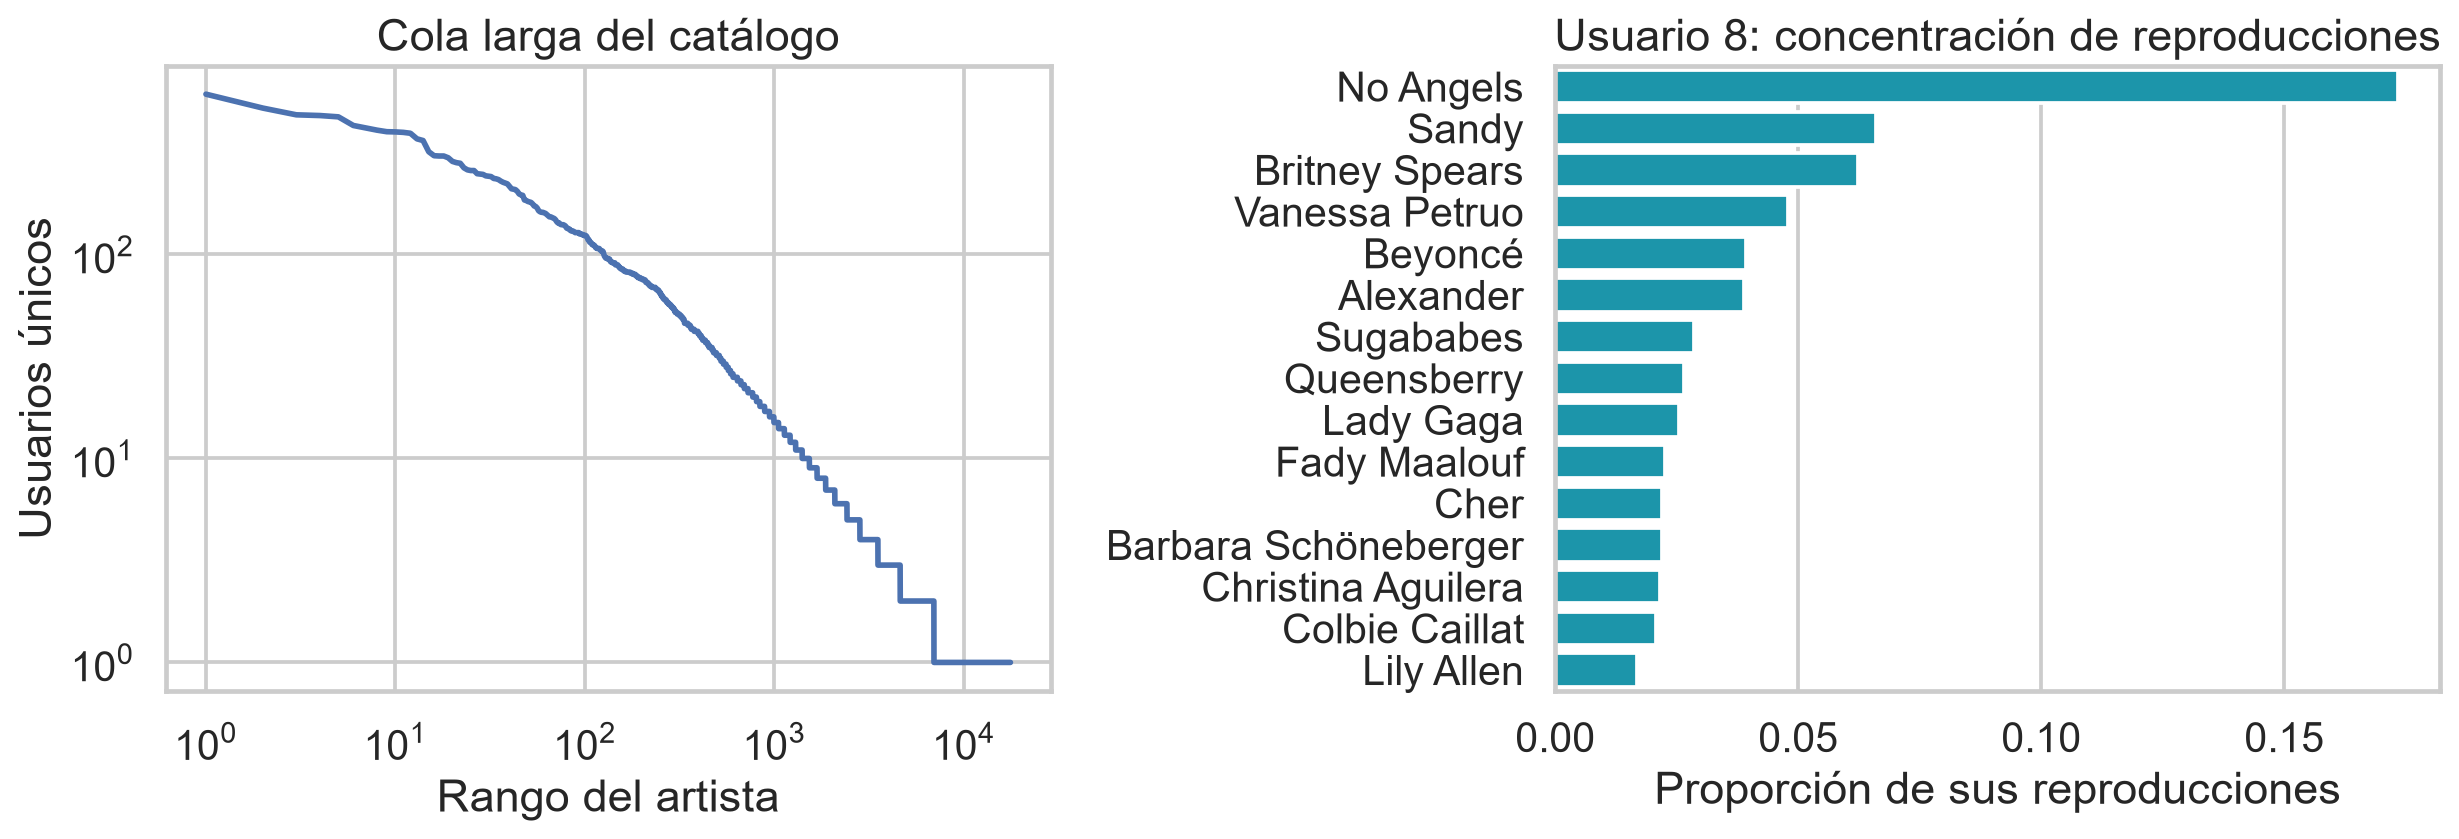

In [4]:
display(Image(filename='figuras/01_estructura_consumo.png'))

In [5]:
popularidad = pd.read_csv('resultados/popularidad_artistas.csv')
display(popularidad.nlargest(10, 'unique_listeners')[['artist_name','unique_listeners','total_plays','rank_listeners','rank_plays']])
display(popularidad.reindex(popularidad['rank_change'].abs().sort_values(ascending=False).index).head(10)[['artist_name','unique_listeners','total_plays','rank_listeners','rank_plays','rank_change']])

,artist_name,unique_listeners,total_plays,rank_listeners,rank_plays
0,Lady Gaga,611,1291387,1,3
1,Britney Spears,522,2393140,2,1
2,Rihanna,484,905423,3,7
3,The Beatles,480,662116,4,9
4,Katy Perry,473,532545,5,10
5,Madonna,429,921198,6,6
6,Avril Lavigne,417,525844,7,11
7,Christina Aguilera,407,1058405,8,4
8,Muse,400,485076,9,19
9,Paramore,399,963449,10,5


,artist_name,unique_listeners,total_plays,rank_listeners,rank_plays,rank_change
3891,Busy Signal,3,19,3522,16225,-12703
5178,Jovem Pan,2,3,4615,17283,-12668
5546,Jeffrey Lewis,2,3,4615,17283,-12668
3848,Vybz Kartel,3,20,3522,16172,-12650
6269,Nicolaus Esterhazy Sinfonia,2,5,4615,17104,-12489
3889,Mr. Vegas,3,28,3522,15837,-12315
5902,Zombie,2,8,4615,16893,-12278
5679,Kitchens of Distinction,2,9,4615,16818,-12203
5332,The Dave Clark Five,2,9,4615,16818,-12203
6009,Pandora,2,10,4615,16745,-12130


### Caso ilustrativo: usuario 8

Las participaciones relativas evitan confundir volumen absoluto con intensidad dentro del perfil. La tabla conserva el conteo original para que la transformación sea auditable.

In [6]:
perfil8 = pd.read_csv('resultados/perfil_usuario_8.csv').sort_values('relative_plays', ascending=False)
display(perfil8[['artist_name','weight','relative_plays']].head(15).round({'relative_plays': 4}))
print('Participación acumulada de sus 5 primeros artistas:', f"{perfil8.head(5)['relative_plays'].sum():.1%}")

,artist_name,weight,relative_plays
0,No Angels,6291,0.1734
1,Sandy,2396,0.0660
2,Britney Spears,2258,0.0622
3,Vanessa Petruo,1735,0.0478
4,Beyoncé,1425,0.0393
5,Alexander,1407,0.0388
6,Sugababes,1039,0.0286
7,Queensberry,963,0.0265
8,Lady Gaga,921,0.0254
9,Fady Maalouf,819,0.0226


Participación acumulada de sus 5 primeros artistas: 38.9%


## 3. Cinco motores comparables

### 3.1 Popularidad simple y ponderada

La versión simple ordena por usuarios únicos. La ponderada suma `log1p(reproducciones)`. Ambas excluyen lo ya escuchado, son baratas y explicables, pero casi no personalizan y refuerzan el bucle “lo visible se vuelve más visible”.

### 3.2 Vecindad por coseno

Se usa filtrado colaborativo usuario-usuario sobre consumo transformado y normalizado, con los 50 vecinos más cercanos. El puntaje de un artista es el consumo normalizado de los vecinos ponderado por su similitud. Es personal y responde rápido a gustos locales, pero necesita solapamiento y puede heredar sesgo de popularidad.

### 3.3 SVD truncada

Se factoriza la matriz normalizada y se reconstruyen puntuaciones para celdas no observadas. Probamos `K ∈ {10,25,50,100}` y elegimos por Recall@10, usando cobertura como desempate. La varianza explicada es descriptiva; para recomendar importa la recuperación fuera de muestra. SVD densifica la señal, pero puede borrar la cola y sus factores no son identificables como géneros sin evidencia externa.

### 3.4 Reglas Apriori

Cada usuario es una canasta binaria. Aplicamos la poda Apriori a pares con soporte mínimo de 5 usuarios; retenemos confianza ≥ 0,05 y lift ≥ 1,20. El ranking agrega `confianza × log2(lift)` desde los antecedentes del perfil. Confianza estima probabilidad condicional; lift descuenta cuán común ya es el consecuente. Para perfiles sin diez candidatos se completa con popularidad ponderada: ocurrió en 26 de 1.892 usuarios.

In [7]:
svd_k = pd.read_csv('resultados/seleccion_k_svd.csv').sort_values('k')
display(svd_k[['k','recall_at_10','mrr_at_10','catalog_coverage','novelty_bits']].round(4))
print('K elegido:', resumen['selected_svd_k'])

,k,recall_at_10,mrr_at_10,catalog_coverage,novelty_bits
1,10,0.1575,0.4441,0.0112,3.4582
0,25,0.1647,0.4532,0.0183,3.8048
2,50,0.1466,0.4249,0.0265,4.2578
3,100,0.1323,0.3907,0.0428,4.8404


K elegido: 25


In [8]:
reglas = pd.read_csv('resultados/reglas_apriori_top.csv')
display(reglas[['antecedent','consequent','support','confidence','lift','rule_score']].head(12).round({'support':4,'confidence':3,'lift':2,'rule_score':3}))

,antecedent,consequent,support,confidence,lift,rule_score
0,Kenny Chesney,Alan Jackson,0.0032,1.000,210.22,7.716
1,Danger Danger,Ratt,0.0032,1.000,135.14,7.078
2,Teairra Mari,Cassie,0.0026,1.000,118.25,6.886
3,Method Man,Wu-Tang Clan,0.0026,1.000,111.29,6.798
4,Proem,Autechre,0.0032,1.000,105.11,6.716
5,Proem,Squarepusher,0.0032,1.000,105.11,6.716
6,Obie Trice,2Pac,0.0026,1.000,99.58,6.638
7,Kenny Chesney,Tim McGraw,0.0026,0.833,225.24,6.513
8,2PM,B2ST,0.0037,0.875,165.55,6.450
9,Tim McGraw,Alan Jackson,0.0032,0.857,180.19,6.423


## 4. ¿Qué recibe el usuario 8?

Las listas muestran el efecto de cada hipótesis. Popularidad repite éxitos globales; coseno trae lo que consumen perfiles próximos; SVD usa proximidad latente; Apriori activa asociaciones explícitas desde artistas ya escuchados. Ningún nombre debe interpretarse como recomendación para 2026.

In [9]:
u8 = pd.read_csv('resultados/recomendaciones_usuario_8_comparadas.csv')
display(u8)

,rank,Apriori,Coseno usuario-usuario,Popularidad ponderada,Popularidad simple,SVD
0,1,Shakira,Madonna,The Beatles,The Beatles,Leona Lewis
1,2,Ke$ha,Kylie Minogue,Madonna,Madonna,Alicia Keys
2,3,Avril Lavigne,Ke$ha,Paramore,Muse,Jordin Sparks
3,4,Miley Cyrus,Shakira,Muse,Avril Lavigne,Glee Cast
4,5,Madonna,Black Eyed Peas,Avril Lavigne,Paramore,Ke$ha
5,6,Kylie Minogue,Miley Cyrus,Radiohead,Radiohead,Adele
6,7,Leona Lewis,Avril Lavigne,Ke$ha,Ke$ha,Jennifer Lopez
7,8,Jennifer Lopez,Jennifer Lopez,Coldplay,Coldplay,Kylie Minogue
8,9,Black Eyed Peas,Glee Cast,Kylie Minogue,Shakira,Girls Aloud
9,10,Ashley Tisdale,Ashley Tisdale,Shakira,Kylie Minogue,Shakira


## 5. Evaluación y ranking de motores

### Evaluación offline

Se oculta aleatoriamente 20% de los pares de cada usuario y se entrena con el 80%. `Recall@10` mide qué fracción de los artistas ocultos reaparece; `MRR@10` premia el primer acierto temprano. Dado el truncamiento, un “falso positivo” puede ser un artista escuchado pero ausente del top 50, por lo que estas métricas son conservadoras.

### Criterio de negocio

El puntaje pondera Recall@10 (35%), cobertura (20%), novedad (15%), personalización (15%) y explicabilidad (15%). Es una decisión normativa alineada con `Descubre`: sacrifica parte de la explotación de popularidad para evitar homogeneizar las listas. La cobertura es sobre los 17.632 artistas del catálogo; la novedad usa auto-información `−log2(popularidad)`.

La participación de cola larga resulta prácticamente nula bajo el umbral empírico empleado: la señal colaborativa por sí sola no rescata artistas de soporte extremadamente bajo. Esto obliga a una cuota explícita de exploración en el producto.

In [10]:
ranking = pd.read_csv('resultados/ranking_motores.csv').sort_values('rank')
cols = ['rank','motor','recall_at_10','mrr_at_10','catalog_coverage','unique_artists_recommended','novelty_bits','personalization','explainability','business_score']
display(ranking[cols].round({'recall_at_10':3,'mrr_at_10':3,'catalog_coverage':4,'novelty_bits':2,'personalization':3,'business_score':3}))

,rank,motor,recall_at_10,mrr_at_10,catalog_coverage,unique_artists_recommended,novelty_bits,personalization,explainability,business_score
0,1,Apriori,0.177,0.511,0.0340,600,3.85,0.945,1.00,0.990
1,2,Coseno usuario-usuario,0.172,0.481,0.0350,617,3.58,0.934,0.85,0.907
2,3,SVD,0.165,0.453,0.0183,323,3.80,0.961,0.45,0.705
3,4,Popularidad simple,0.070,0.189,0.0015,27,2.44,0.417,1.00,0.151
4,5,Popularidad ponderada,0.070,0.190,0.0016,29,2.44,0.416,1.00,0.151


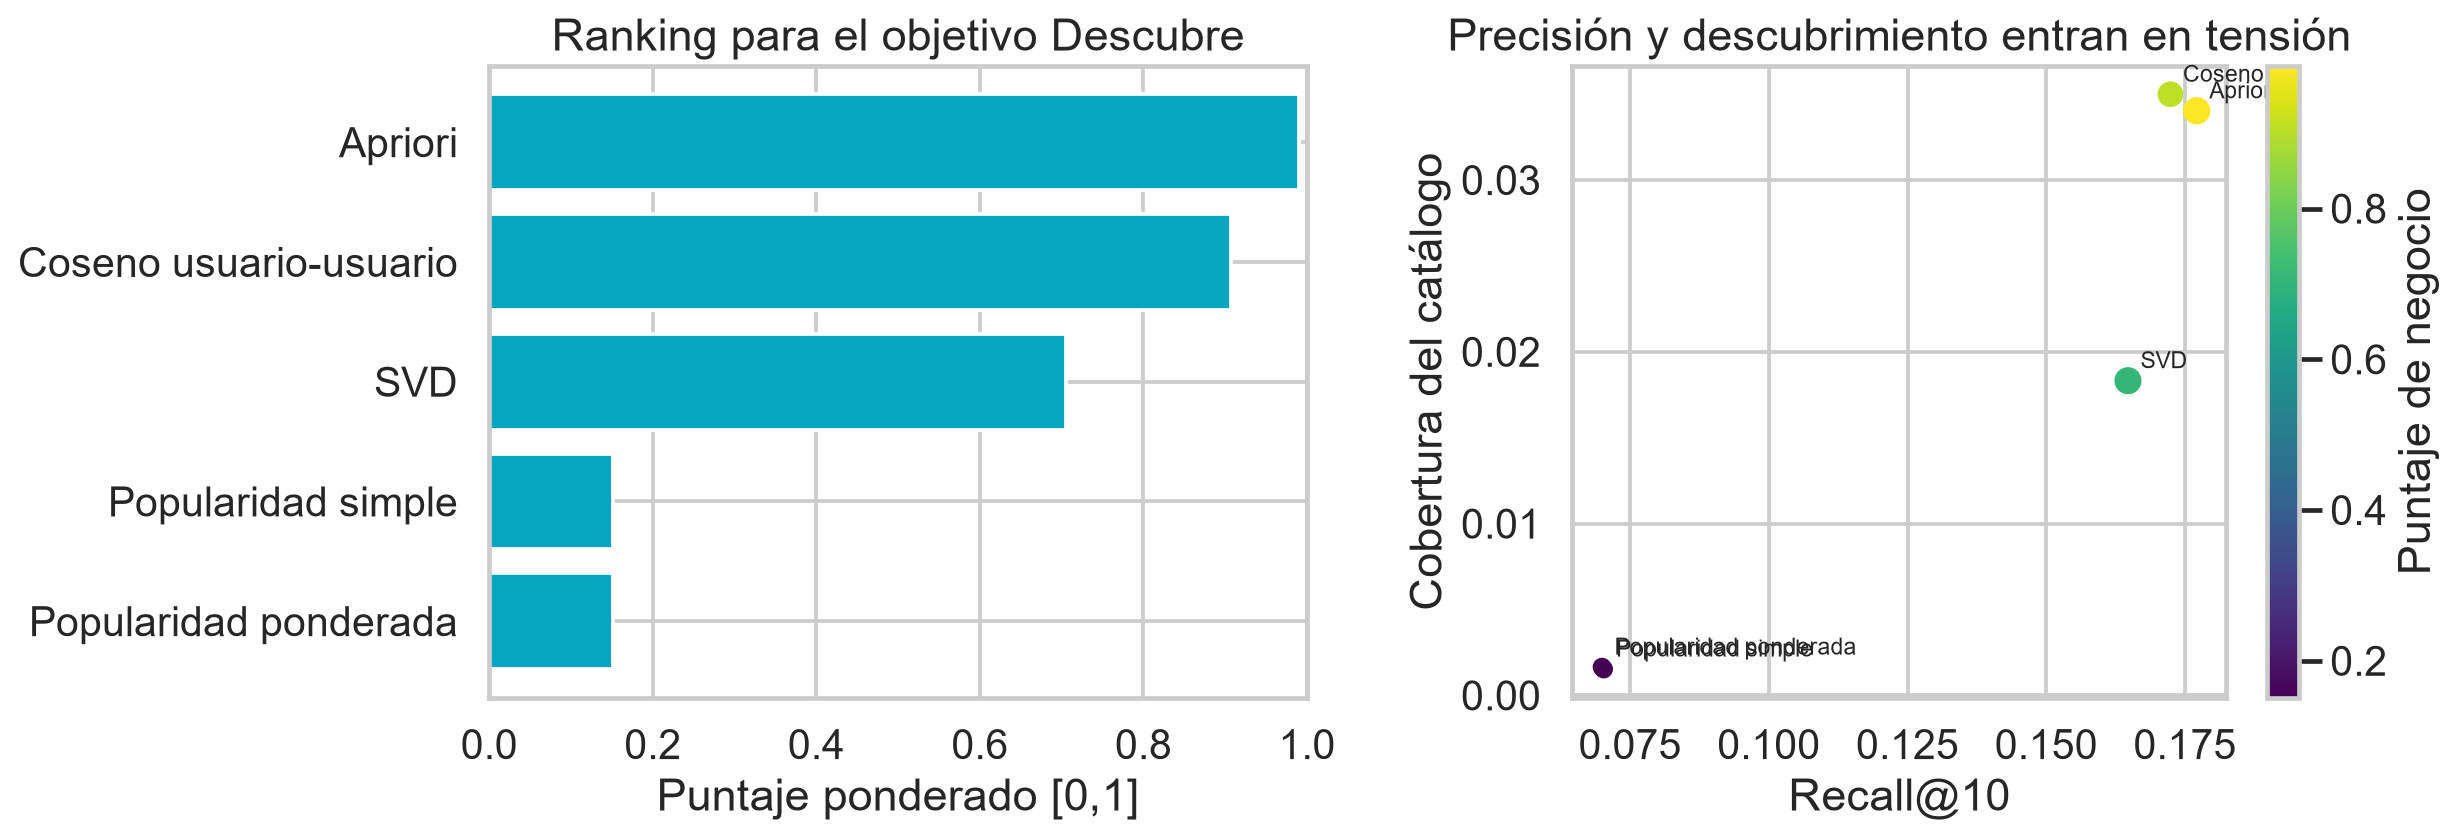

In [11]:
display(Image(filename='figuras/02_ranking_motores.png'))

## 6. Recomendación, condiciones y salvaguardas

**Decisión solicitada:** autorizar un piloto limitado de Apriori frente a la línea base de popularidad, no un lanzamiento general.

Configuración inicial:

1. Ocho posiciones Apriori, una posición de exploración de catálogo elegible y una posición de respaldo; excluir artistas ya escuchados.
2. Tope de exposición por artista y por sello; monitorear concentración (Gini/Herfindahl), cobertura y participación de sellos independientes.
3. Filtros de seguridad y elegibilidad editorial antes del ranking; no usar atributos sensibles ni inferidos.
4. Explicación visible “porque escuchaste X”; registrar regla, versión y puntaje para auditoría.
5. Respaldo de popularidad ponderada solo cuando no haya diez reglas; alertar si ese fallback supera 5% de usuarios.
6. Reentrenamiento y deriva: vigilar soporte, lift, cobertura y cambio de catálogo; retirar reglas obsoletas.

Trade-off aceptado: Apriori explota coocurrencias plausibles y explicables, pero no hace visible por sí solo el 60,6% del catálogo con un solo oyente. La posición de exploración es necesaria para aprender sobre esa cola sin convertir a los usuarios en sujetos de recomendaciones arbitrarias.

## 7. Diseño de la prueba A/B

- **Control:** popularidad ponderada excluyendo escuchados.
- **Tratamiento:** Apriori con las salvaguardas anteriores.
- **Unidad:** usuario; asignación persistente y aleatoria. Estratificar por antigüedad y actividad.
- **Métrica primaria:** proporción de usuarios que inicia reproducción de un artista recomendado y supera 30 segundos, con horizonte de 7 días.
- **Secundarias:** guardado/seguimiento, artistas nuevos escuchados por usuario, diversidad intra-lista, cobertura, retorno a 7/28 días.
- **Guardrails:** skips tempranos, ocultamientos, quejas, latencia, concentración de exposición y fallback.
- **Lectura causal:** estimar diferencia e intervalo de confianza; predefinir tamaño de muestra y duración para cubrir estacionalidad. No detener por significancia temprana.

La validación offline se debe rehacer con datos actuales y corte temporal antes del experimento. Un resultado online exitoso exige mejora en descubrimiento sin deteriorar guardrails, no solo más clics.

## 8. Limitaciones y próximos pasos

- Last.fm 2011 no representa el catálogo ni los hábitos actuales de la plataforma.
- No hay tiempo: el holdout aleatorio puede filtrar patrones que no existirían al momento de recomendar.
- Solo observamos top 50; ausencia no es rechazo y las métricas subestiman relevancia verdadera.
- Apriori excluye relaciones raras por soporte; SVD y coseno también requieren señal compartida. El cold start necesita contenido/editorial o exploración.
- Los pesos del ranking expresan prioridades de negocio y deben aprobarse con producto, catálogo y responsables de equidad.

Próximo paso: repetir con logs actuales, split temporal, deduplicación/bots, metadatos de género/sello y evaluación por segmentos; después ejecutar el A/B con criterio de éxito pre-registrado.

## Referencias del curso y datos

- GroupLens, HetRec 2011 Last.fm 2K Dataset (archivos suministrados `artists.txt` y `user_artists.txt`).
- Laboratorios Semana 5: introducción a recomendadores, análisis de canasta y filtrado colaborativo/SVD.
- Guías de estudio Semana 5: sistemas de recomendación; filtrado colaborativo, SVD y pruebas A/B.

Todo resultado numérico de esta entrega se genera localmente a partir de los archivos suministrados.